<a href="https://colab.research.google.com/github/ahana2611/Self-study-Projects/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
medical = pd.read_csv("medical_dataset_realistic_v2.csv")

In [ ]:
# Convert timestamp
medical["timestamp"] = pd.to_datetime(medical["timestamp"], errors="coerce")

In [ ]:
numeric_features = [
    "age",
    "duration_hours",
    "temp_c",
    "heart_rate",
    "systolic_bp",
    "diastolic_bp",
    "wbc_count",
    "nurse_contact_count",
    "surface_contamination_score",
    "ventilation_quality_index",
]

for column in numeric_features:
    medical[column] = pd.to_numeric(medical[column], errors="coerce")


In [ ]:
binary_features = ["prior_admissions_6months", "antibiotic_resistance_marker", "MDR_label"]
for column in binary_features:
    medical[column] = pd.to_numeric(medical[column], errors="coerce")

In [ ]:
# 4. Feature engineering from timestamp
medical["hour"] = medical["timestamp"].dt.hour
medical["dayofweek"] = medical["timestamp"].dt.dayofweek

In [ ]:
# You can drop timestamp if you don’t want raw datetime
medical = medical.drop(columns=["timestamp"])

Outlier detection with boxplots

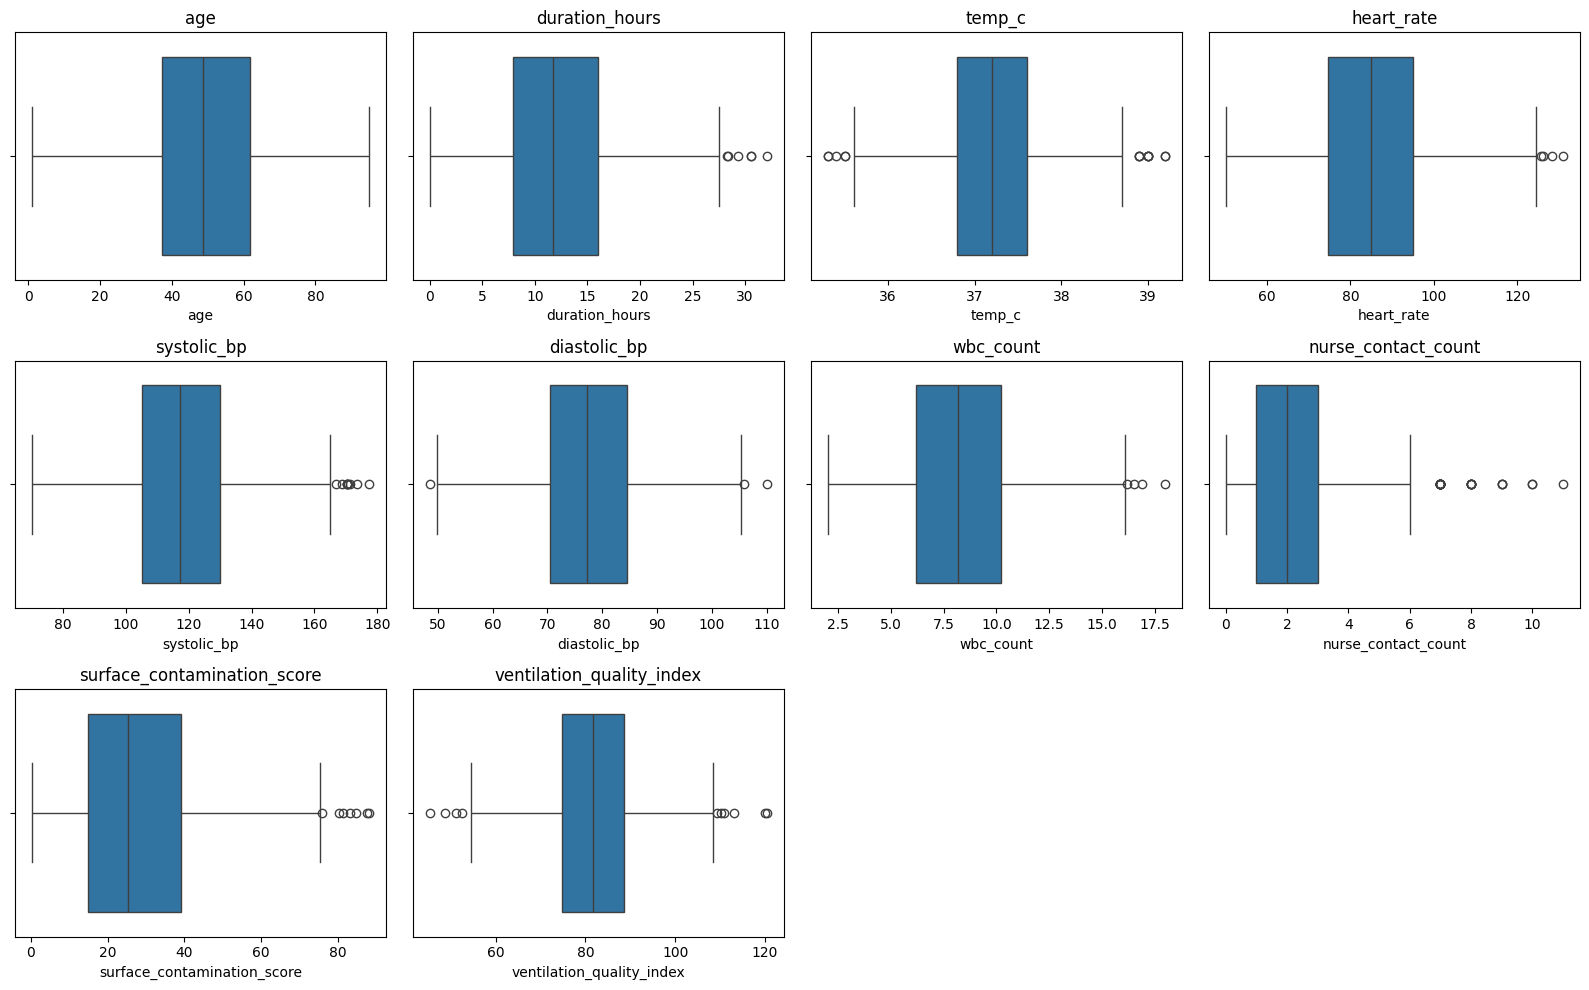

In [ ]:
continuous_for_outliers = numeric_features  # focus on continuous values

plt.figure(figsize=(16, 10))
for i, column in enumerate(continuous_for_outliers, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x=medical[column])
    plt.title(column)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import RobustScaler

In [ ]:
medical['surface_contamination_score'] = np.log1p(medical['surface_contamination_score'])

In [ ]:
# 6. Outlier handling function (IQR capping / winsorization)
def cap_outliers_iqr(data, cols, factor=1.5):
    data = data.copy()
    for column in cols:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
        data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])
    return data

medical = cap_outliers_iqr(medical, continuous_for_outliers)

In [ ]:
# 7. Define features and target
target_value = "MDR_label"

In [ ]:
# Drop obvious identifiers (patient_id) from features
medical = medical.drop(columns=["patient_id"])

In [ ]:
data = medical.drop(columns=[target_value])
target = medical[target_value]

In [ ]:
# 8. Define column types for the pipeline
numeric_features = numeric_features + ["hour", "dayofweek", "prior_admissions_6months", "antibiotic_resistance_marker"]

categorical_features = [
    "gender",
    "ward",
    "movement_path",
    "equipment_used",
    "comorbidity",
    "sputum_result",
    "antibiotic_given",
]

# Make sure any missing categorical columns don’t break the code
existing_categoriess = [c for c in categorical_features if c in X.columns]
categorical_features = existing_categories


In [ ]:
# 9. Preprocessing pipelines

# Numeric: impute (median) + standardise (mean=0, std=1)
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),   # standardisation / normalisation
    ]
)

In [ ]:
# Categorical: impute (most frequent) + OneHotEncode
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)


In [ ]:
# Combine them
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",  # drop any columns not specified
)

In [ ]:
# 10. Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    data,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target,
)

In [ ]:
# 11. Full modelling pipeline (example: Logistic Regression)
clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)


In [ ]:
# 12. Fit the model
clf.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'duration_hours',
                                                   'temp_c', 'heart_rate',
                                                   'systolic_bp',
                                                   'diastolic_bp', 'wbc_count',
                                                   'nurse_contact_count',
                                                   'surface_contamination_score',
                                                   'ventilation_quality_index',
                                                   'hour', 'dayofweek',
                                                   'prior_admissions_6months',
                                                   'antibiotic_resistance_marker']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'ward',
                                                   'movement_path',
                                                   'equipment_used',
                                                   'comorbidity',
                                                   'sputum_result',
                                                   'antibiotic_given'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
# 13. Evaluate quickly
from sklearn.metrics import classification_report

# **Logistic Regression Performance**

In [ ]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       278
           1       0.75      0.27      0.40        22

    accuracy                           0.94       300
   macro avg       0.85      0.63      0.68       300
weighted avg       0.93      0.94      0.93       300



**Observations:**
the dataset is imbalanced, so this model is not a right fit for our dataset